# Linear Methods for Classification

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

We first load the train and test data, and do some cleaning

In [17]:
train = pd.read_csv("Linear Methods for Classification/vowel_train.csv", sep=",")

train["x.10"] = (
    train["x.10\\"]
    .astype(str)
    .str.replace("\\", "", regex=False)
    .str.replace("}", "", regex=False)
    .astype(float)
)

train = train.drop(columns=["x.10\\"])


test = pd.read_csv("Linear Methods for Classification/vowel_test.csv", sep=",")

test["x.10"] = (
    test["x.10\\"]
    .astype(str)
    .str.replace("\\", "", regex=False)
    .str.replace("}", "", regex=False)
    .astype(float)
)

test = test.drop(columns=["x.10\\"])

print(train.head())
print(train.describe())




   y    x.1    x.2    x.3    x.4    x.5    x.6    x.7    x.8    x.9   x.10
1  1 -3.639  0.418 -0.670  1.779 -0.168  1.627 -0.388  0.529 -0.874 -0.814
2  2 -3.327  0.496 -0.694  1.365 -0.265  1.933 -0.363  0.510 -0.621 -0.488
3  3 -2.120  0.894 -1.576  0.147 -0.707  1.559 -0.579  0.676 -0.809 -0.049
4  4 -2.287  1.809 -1.498  1.012 -1.053  1.060 -0.567  0.235 -0.091 -0.795
5  5 -2.598  1.938 -0.846  1.062 -1.633  0.764  0.394 -0.150  0.277 -0.396
                y         x.1         x.2         x.3         x.4         x.5  \
count  528.000000  528.000000  528.000000  528.000000  528.000000  528.000000   
mean     6.000000   -3.166695    1.735343   -0.448002    0.524983   -0.389280   
std      3.165277    0.957965    1.160970    0.741363    0.769361    0.722011   
min      1.000000   -5.211000   -1.274000   -2.487000   -1.409000   -2.127000   
25%      3.000000   -3.923000    0.916750   -0.945500   -0.083500   -0.930750   
50%      6.000000   -3.097000    1.733000   -0.502500    0.45650

<Axes: >

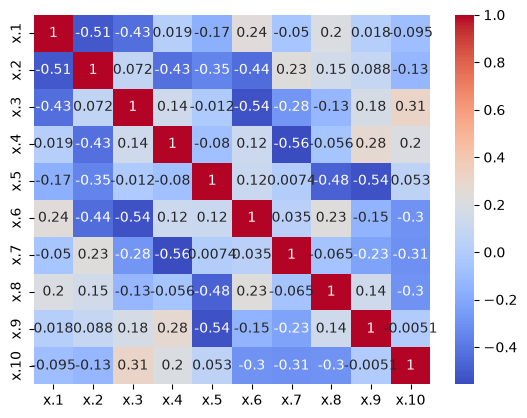

In [ ]:
correlations = train.loc[:, train.columns != 'y'].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

In [ ]:
for k in range(1, 12):
    train[f"y_{k}"] = (train["y"] == k).astype(int)
    test[f"y_{k}"] = (test["y"] == k).astype(int)


x_vars = [f"x.{k}" for k in range(1, 11)]

models = []

for k in range(1, 12):
    
    y = train[f"y_{k}"]
    
    X = sm.add_constant(train[x_vars])
    
    model = sm.OLS(y, X).fit()
    
    models.append(model)

fitted_train = pd.DataFrame({
    f"y_{k}": models[k-1].fittedvalues
    for k in range(1, 12)
})

prediction_train = np.argmax(
    fitted_train.to_numpy(),
    axis=1
) + 1

train_error_rate = np.mean(
    train["y"].to_numpy() != prediction_train
)

print("Training error rate:", train_error_rate)


X_test = sm.add_constant(test[x_vars])

fitted_test = pd.DataFrame({
    f"y_{k}": models[k-1].predict(X_test)
    for k in range(1, 12)
})

prediction_test = np.argmax(
    fitted_test.to_numpy(),
    axis=1
) + 1

test_error_rate = np.mean(
    test["y"].to_numpy() != prediction_test
)

print("Test error rate:", test_error_rate)

Training error rate: 0.4772727272727273
Test error rate: 0.6666666666666666
